## Author: Abdelaziz Neamatallah
### Date: 24.10.25
### Desc: This task should show the similarity between different datasets.

- The goal of this task is to analyze the similarity of the provided network traffic between the different files, in which it was collected. 
- So, we need to write a piece of code that satisfies the following requirements

1. For each of our datasets, we need to generate **traffic flows** from the corresponding network traffic.
    - Each flow should correspond to a time window of {2,4,6} mins and should only contain traffic exchanged between two communicating parties over the same highest-lecel protocol.
   - From the corresponding sequence of packets belonging to a given flow, we should extract only:
     - packet size
     - direction
     - inter-arrival packet time
   - All flows should have the same length.
   - And we should ensure that we do not lose information for longer flows.
   - Finally, we should differentiate between flows containing packets under attack, and those without attacks.

- Now lets try to understand some basic concepts before we proceed.
- Traffic flow mean: 
  - Think of the PCAP dataset as a long list of packets captured over time, which includes thousands of messages exchanged between many devices. 
  - A flow is a group of packets, that all belong to the same communication session between two hosts using the same protocol within a given time window.
  - in other words: all packets sent between host A and host B over the same protocol during X minutes. 
  - usually the traffic will looks like:

| Time (s) | Source       | Destination  | Protocol | Length | Attack? |
| -------- | ------------ | ------------ | -------- | ------ | ------- |
| 0.1      | 192.168.1.10 | 192.168.1.20 | S7comm   | 120    | No      |
| 0.2      | 192.168.1.20 | 192.168.1.10 | S7comm   | 130    | No      |
| 10.5     | 192.168.1.11 | 192.168.1.30 | HTTP     | 900    | Yes     |

  - So, you can see the first two packets are between the same pair using the same protocol, so they belong to one flow, and the last one is different so it belongs to another flow.
- Now, after we understood what does traffic flow means, we need o generate traffic flows for three durations:
  - 2 minutes
  - 4 minutes
  - 6 minutes
- this mean that we need to slice the whole capture timeline into chunks of 2,4, and 6 minutes each
  - 0:0 - 0:2 => flow window 1
  - 0:2 - 0:4 => flow window 2
- inside each window, we should group the packets by:
  - same source IP, destination IP, and protocol
  - each group will represent one flow.
- Then we should extract features from packets inside each flow
  - Packet size
  - Directions
  - Inter-arrival time (IAT): this is the time difference between consecutive packets in that flow, so each flow should look like a triplets.  
- It was mentioned that we need to diffrentiate between the packets marked as attacked, and other marked as normal.
- Also, all flows should have the same length. 

### Understanding of the datasets:
#### 2017QUT_S7Comm
- It consists of 3 sub-directories
  1. Graphs: 
  
| File / Folder              | Description                                                                                                                                                        |
| -------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **`tshark_attacks`**       | Output of `tshark` (Wireshark CLI) during attack captures — lists packets, timestamps, fields (like function codes, packet sizes, etc.) for sessions under attack. |
| **`tshark_control`**       | Same, but for *normal (control)* traffic — used as baseline.                                                                                                       |
| **`gnuplot_graphs.gplot`** | A **Gnuplot** script that plots network statistics (e.g., number of S7 packets per second). Used to reproduce figures in their publication.                        |
| **`SCADA_traffic.ps`**     | PostScript plot (graph) showing SCADA traffic volume or timing patterns — likely an exported visualization.                                                        |

  2. LabeledDataset: => this is the core folder for us
     - It consists of 2 labeled datasets:
       - control_set: describes the regular operating procedure without incidents
       - s7_process_attacks: describes an operational sequence that is manipulated by an attacker 
  3. Logs:
     - Stores experiment log files from each participant system
- So, we can conclude that we will interact only with the LabeledDataset folder  

### Understanding the structure of s7_process_attacks:
- They captured network traffic from several network interfaces
  - Master: PLC or central controller
  - HMI: From the Human machine interface
  - Attacker: attacker traffic
- This contains one complete attack experiment, and these are the key files
    - master.pcap => these are the packets captured on the PLC or controller side, shows legitimate and injected commands received => this is the main dataset to analyze in our task
    - hmi.pcap => packets captured on the HMI (SCADA interface) side => also useful to be analyzed
    - attacker.pcap => Traffic seen by the attacking host, includes crafted malicious S7comm packets
- Then there is a folder called 20161215202830 => this looks like a date and time (2016/12/15 at 20:28:30 o'clock)
  - it contains subfolders each with a date then . the source of these data, and each folder contains some pcap files, following the same structure also
    - master
    - hmi
    - attacker
- I think, but I am not sure, that the attacker.pcap is a collection for all these sub-folders.pcap
- and same for hmi, and master. => Ask Dr. Asya
- List of process attacks:
  - 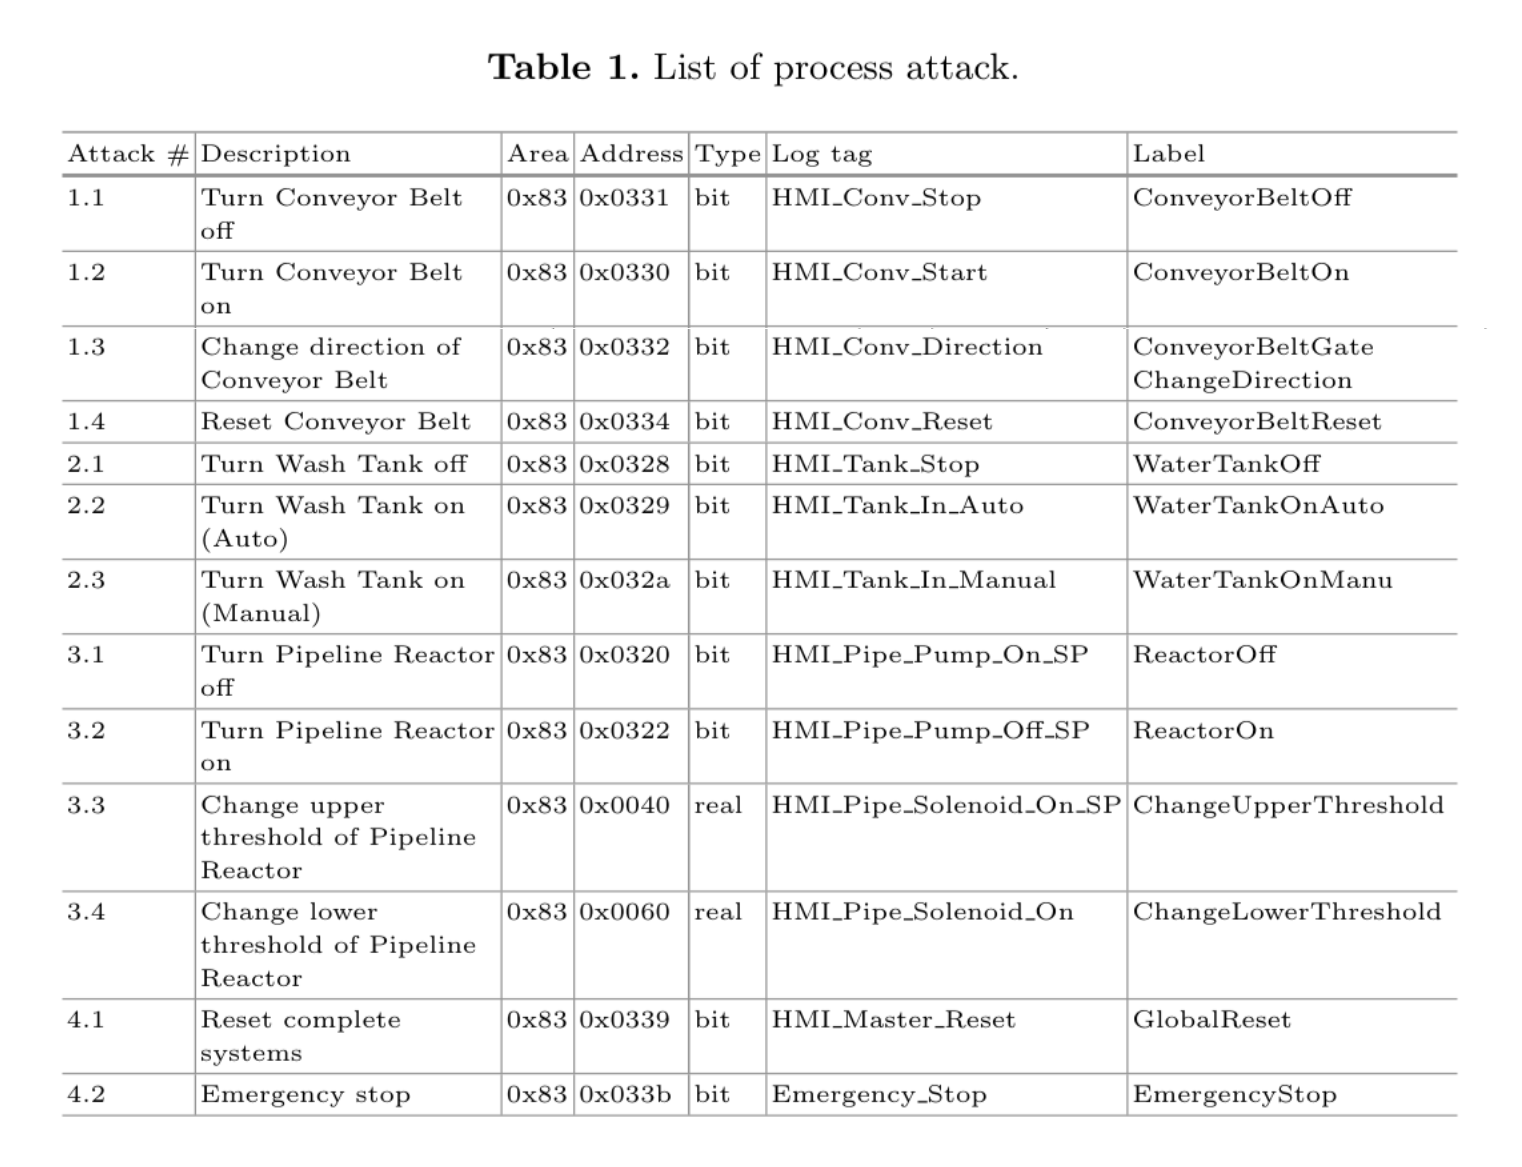
- All process attacks (64)
  - 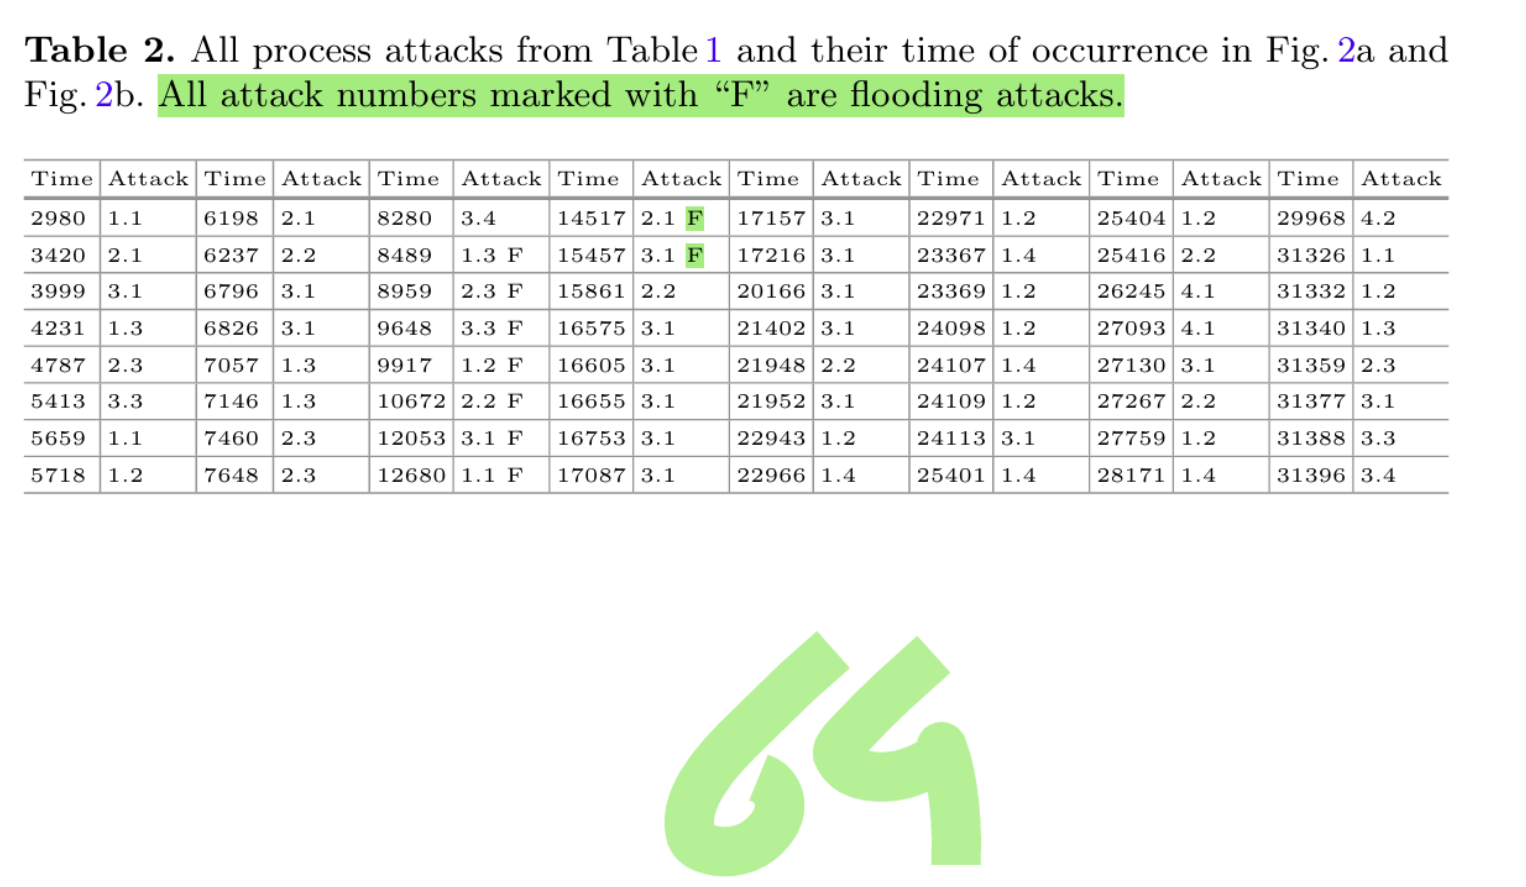

### Understanding of control_set
- This is much easier, it just contains three sub-files
  - Attacker.pcap
  - HMI.pcap
  - master.pcap

### Understanding of electra_S7comm dataset
- this is a .csv file, it is not pcap, should we handle it as is?
- [Dataset explaination](http://perception.inf.um.es/ICS-datasets/)
- There are Three categories and seven classes of attacks in the Electra dataset
  - 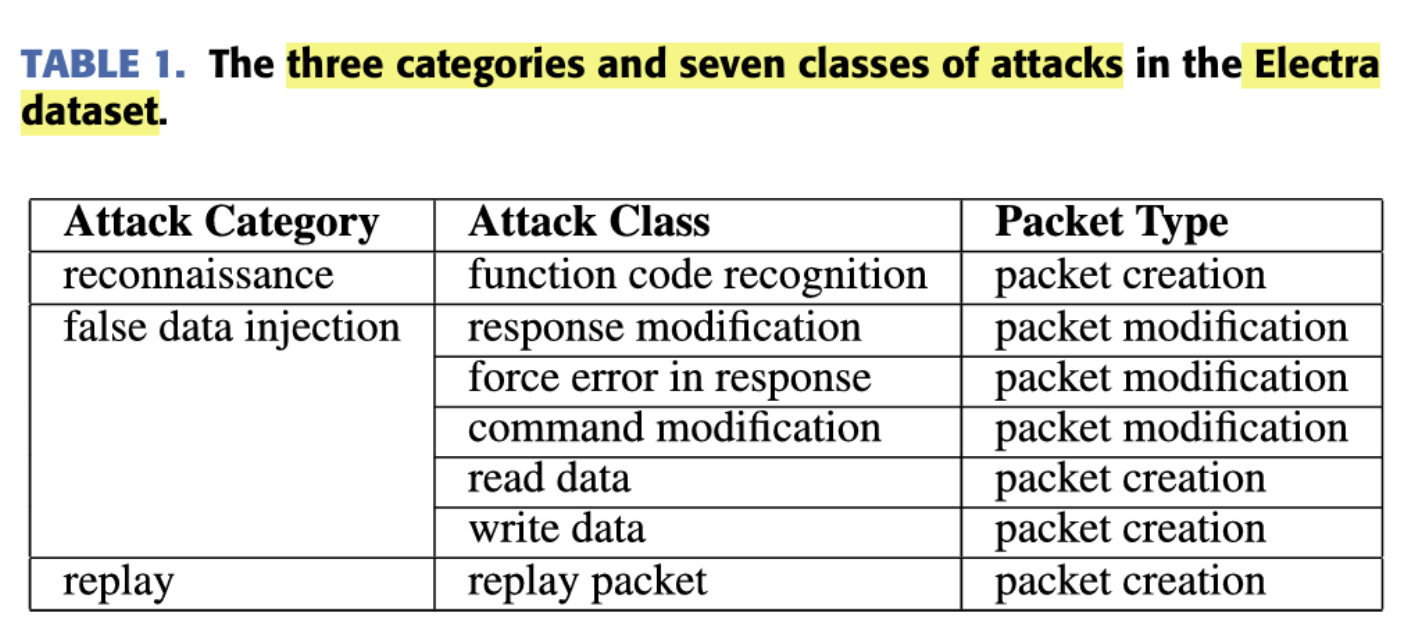
- Reconnaissance attacks: They are aimed at identifying  potential victims within a network. After gaining access to an industrial network, an attacker needs to perform a reconnaissance attack to get information about the different devices that are in the network and their associated services. From this information, the attacker usually plans the next move.
-  False data injection attacks: They are aimed at controlling the control devices of an ICS. To achieve this goal, these attacks are based on sending altered data through control protocols. False data injection attacks can be classi ed depending on the data they alter into: Command Injection, Response Injection and Parameter Injection, just to name a few.
- Replay attacks: They are based on retransmitting valid packets that have been previously seen in the network. This action can alter the normal reception rate of that packet in a device or can mislead a device by sending an unexpected but apparently valid packet to it. In ICS, these attacks can have as much impact as the false data injection attacks, but they are harder to detect because the packet payload is valid.

### How Electra Dataset has been generated
- It is an electric traction substation employed in a real high-speed railway industry, the main goal is to convert the electric power into voltage, current, and frequency to supply railways or trams. This system can be used to convert the three-phase AC current to single-phase with the lower frequency needed for rail-way electrical system. 
- The system consists of the following architecture:
  - 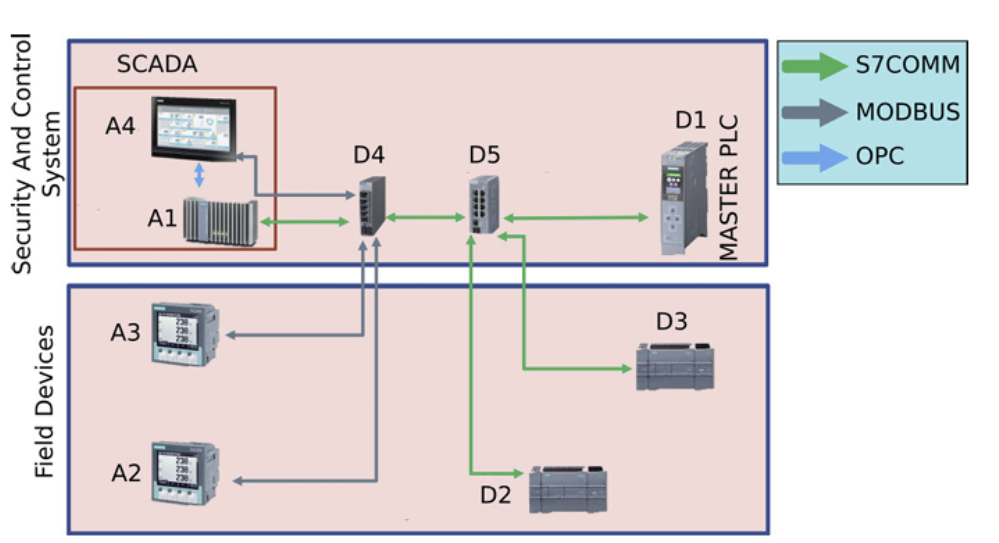
    - it has 5 PLCs ( 1 master, and 4 slaves )
    - switch called D5 for the interconnection of the different devices.
    - firewall called D4 to protect the substation from attacks coming from outside. 
    - The testbed communicate through control protocols following master-slave architecture, where the master initiates the communication requesting some data, and a slave replies with the requested information.
    - They use the following protocols:
      - Modbus TCP
      - S7comm
      - OPC
    - SCADA System consists of
      - HMI (A4)
      - Nanobox (A1)
      - they communicate via OPC protocol
      - The SCADA acts as the master for the two SCADA slaves (A2) and (A3)
    - Similarly for the S7comm:
      - D1 PLC acts as the master for (A1, D2, D3)
- Here are the IP and MAC addresses for the devices on the system:
  
  - 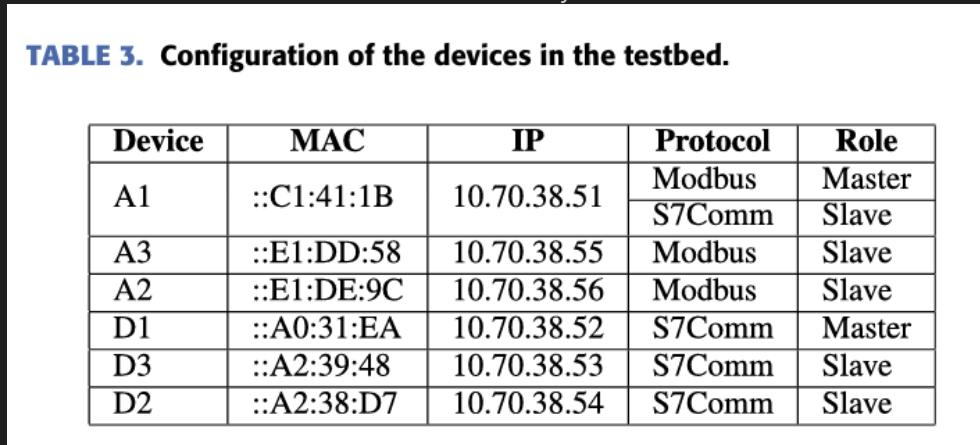
  - 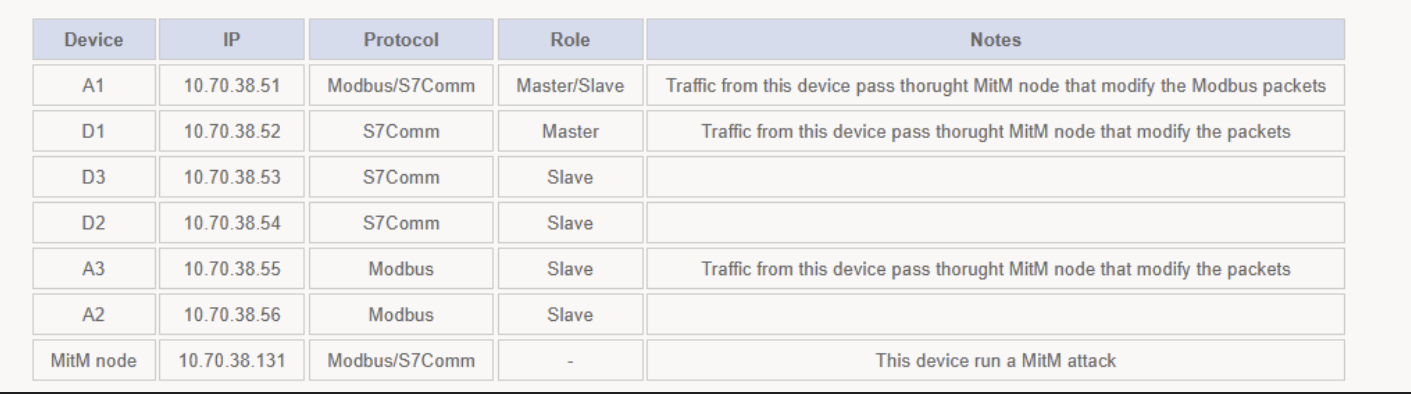
- The attacked nodes for S7comm shuld be D1 and D2
- Traffic on S7comm should be on port 102
- Spectra selected features: 
  - 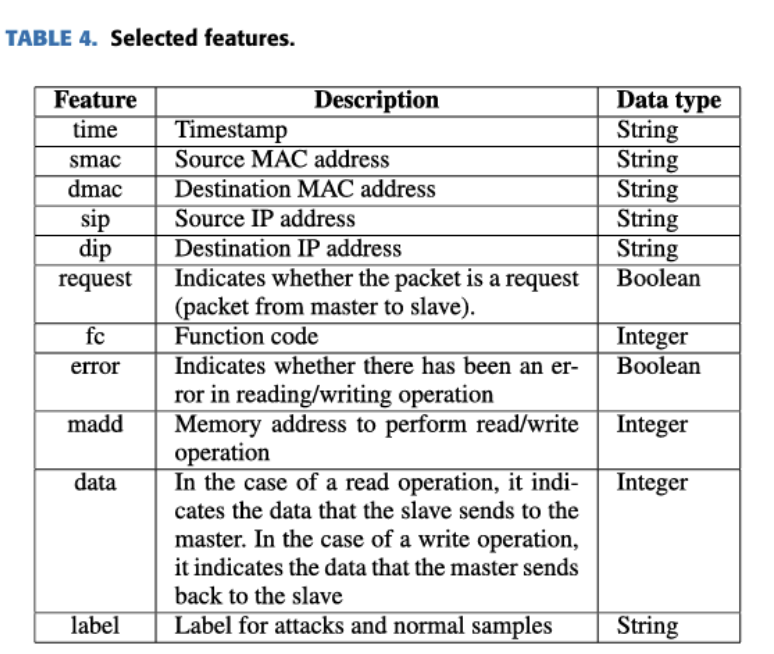

- This notebook is a playground, to perform our analysis on small portion of the data, to understand how things works, then we can transfer our knowledge then to other notebooks.

In [61]:
import sys
sys.path.append('../../Anna_Code')  
from file_helper import *



In [62]:


#load all csv files into one dataframe
#used forQUT S7Comm
# Abdelaziz Comment: It would be better if we added the path as parameter, so I can also use them
def load_all_csvs(attack_path = "/home/dW5kZWFk/uni/study_project/datasets/output/2017QUT_S7comm/attacks/", control_path="/home/dW5kZWFk/uni/study_project/datasets/output/2017QUT_S7comm/control/"):
    # Get all .csv files recursively (or non-recursively)
    csv_files_attack = list_files_by_filetype(attack_path,"csv")
    csv_files_control = list_files_by_filetype(control_path,"csv")
    csv_files=csv_files_attack+csv_files_control
    dfs = []


    for f in csv_files:
        try:
            df = pd.read_csv(f)
            dfs.append(df)
        except Exception as e:
            print(f"⚠️  Skipping {f}: {e}")


    combined = pd.concat(dfs, ignore_index=True)
    print(f"✅ Combined DataFrame shape: {combined.shape}")
    return combined

In [63]:

#for each pcap file create a csv file using the pcap_extract_values function
#no csv created for empty files
def create_csv_files( 
        attack_path = '../../DataSets/2017QUT_S7comm/LabelledDataset/20161215163606_s7_process_attacks',
        control_path='../../DataSets/2017QUT_S7comm/LabelledDataset/20161219132813_control_set'  ,
        output_base_path_attack="/home/dW5kZWFk/uni/study_project/datasets/output/2017QUT_S7comm/attacks/",
        output_base_path_control = "/home/dW5kZWFk/uni/study_project/datasets/output/2017QUT_S7comm/control/"
  
        ):

    pcap_files_attack=list_files_by_filetype(attack_path,"pcap")
    pcap_files_control=list_files_by_filetype(control_path,"pcap")
    print(len(pcap_files_attack))
    print(len(pcap_files_control))

    for path in pcap_files_control:
        try:
            filename = os.path.basename(path)
            df_pcap=pcap_extract_values(path, 0)
            save_df_to_csv(df_pcap, output_base_path_control+filename+".csv")
            print(f"File {path} done.")
        except Exception as e:
            print(f"Exception in {filename}:\n{e}")

    print("\n\nControl dataset done\n\n")

    for path in pcap_files_attack:
        try:
            filename=os.path.basename(path)
            df_pcap = pcap_extract_values(path, 1)
            save_df_to_csv(df_pcap, output_base_path_attack+filename+".csv")
            print(f"File {path} done.")
        except Exception as e:
            print(f"Exception in {path}:\n{e}")
            os.path.getsize(path)

    return 0


In [64]:
# create_csv_files(

#     '../../DataSets/2017QUT_S7comm/LabelledDataset/20161215163606_s7_process_attacks',
#     '../../DataSets/2017QUT_S7comm/LabelledDataset/20161219132813_control_set'  ,
#     '../../DataSets/2017QUT_S7comm/LabelledDataset/output/2017QUT_S7comm/attacks/'  ,
#     '../../DataSets/2017QUT_S7comm/LabelledDataset/output/2017QUT_S7comm/control/'  ,
# )
# This took 24 minutes to run on my PC
# do not run it again unless you need to recreate the csv files

## Creating Traffic flow for Attacker Dataset

In [65]:

df_attacks = load_all_csvs(
    '../../DataSets/2017QUT_S7comm/LabelledDataset/output/2017QUT_S7comm/attacks/',
)

df_attacks.head()

✅ Combined DataFrame shape: (3635038, 15)


,timestamp,src_ip,dst_ip,src_port,dst_port,l4_proto,app_proto,frame_len,total_header_len,app_payload_len,pair_id,iat_pair,iat_proto_pair,label_attack,filename
0,1.481787e+09,10.10.10.66,10.10.10.10,49610,102,TCP,s7comm,90,54,36,10.10.10.10__10.10.10.66,NaN,NaN,1,20161215172609.ConveyorBeltOff.attacker.pcap
1,1.481787e+09,10.10.10.10,10.10.10.66,102,49610,TCP,s7comm,76,54,22,10.10.10.10__10.10.10.66,0.003519,0.003519,1,20161215172609.ConveyorBeltOff.attacker.pcap
2,1.481787e+09,10.10.10.66,10.10.10.10,49610,102,TCP,s7comm,90,54,36,10.10.10.10__10.10.10.66,0.000736,0.000736,1,20161215172609.ConveyorBeltOff.attacker.pcap
3,1.481787e+09,10.10.10.10,10.10.10.66,102,49610,TCP,s7comm,76,54,22,10.10.10.10__10.10.10.66,0.003264,0.003264,1,20161215172609.ConveyorBeltOff.attacker.pcap
4,1.481787e+09,10.10.10.66,10.10.10.10,49610,102,TCP,s7comm,90,54,36,10.10.10.10__10.10.10.66,NaN,NaN,1,20161215172609.ConveyorBeltOff.master.pcap


In [66]:
# select only timestamp, src_ip, dst_ip, l4_proto, app_proto_ frame_len, pair_id, filename 
df_attacks_selected_features = df_attacks[['timestamp', 'src_ip', 'dst_ip', 'app_proto', 'frame_len', 'pair_id']]
df_attacks_selected_features.head()

,timestamp,src_ip,dst_ip,app_proto,frame_len,pair_id
0,1.481787e+09,10.10.10.66,10.10.10.10,s7comm,90,10.10.10.10__10.10.10.66
1,1.481787e+09,10.10.10.10,10.10.10.66,s7comm,76,10.10.10.10__10.10.10.66
2,1.481787e+09,10.10.10.66,10.10.10.10,s7comm,90,10.10.10.10__10.10.10.66
3,1.481787e+09,10.10.10.10,10.10.10.66,s7comm,76,10.10.10.10__10.10.10.66
4,1.481787e+09,10.10.10.66,10.10.10.10,s7comm,90,10.10.10.10__10.10.10.66


In [67]:
# show the unique app_proto
print(df_attacks_selected_features['app_proto'].unique())

['s7comm' 'undetected:-1:-1' 'DHCPv6 Client' 'NBDS' 'NTP' 'NBNS' 'mDNS'
 'llmnr']


In [68]:
# drop any packet with undefined app_proto and any packet with no src_ip or dst_ip
df_attacks_selected_features = df_attacks_selected_features[df_attacks_selected_features['app_proto'] != 'undetected:-1:-1']
df_attacks_selected_features = df_attacks_selected_features[df_attacks_selected_features['src_ip'].notna() & df_attacks_selected_features['dst_ip'].notna()]
print(df_attacks_selected_features.head())


      timestamp       src_ip       dst_ip app_proto  frame_len  \
0  1.481787e+09  10.10.10.66  10.10.10.10    s7comm         90   
1  1.481787e+09  10.10.10.10  10.10.10.66    s7comm         76   
2  1.481787e+09  10.10.10.66  10.10.10.10    s7comm         90   
3  1.481787e+09  10.10.10.10  10.10.10.66    s7comm         76   
4  1.481787e+09  10.10.10.66  10.10.10.10    s7comm         90   

                    pair_id  
0  10.10.10.10__10.10.10.66  
1  10.10.10.10__10.10.10.66  
2  10.10.10.10__10.10.10.66  
3  10.10.10.10__10.10.10.66  
4  10.10.10.10__10.10.10.66  


In [69]:
print(df_attacks_selected_features.pair_id.unique())

['10.10.10.10__10.10.10.66' '10.10.10.10__10.10.10.20'
 '10.10.10.20__10.10.10.255' '10.10.10.200__255.255.255.255'
 '10.10.10.66__224.0.0.251' '169.254.133.89__169.254.255.255'
 '169.254.133.89__224.0.0.252' '10.10.10.20__224.0.0.252']


In [70]:
# group packets by application protocol
df_attacks_grouped = df_attacks_selected_features.groupby(['app_proto', 'pair_id'])

df_attacks_grouped.head()

,timestamp,src_ip,dst_ip,app_proto,frame_len,pair_id
0,1.481787e+09,10.10.10.66,10.10.10.10,s7comm,90,10.10.10.10__10.10.10.66
1,1.481787e+09,10.10.10.10,10.10.10.66,s7comm,76,10.10.10.10__10.10.10.66
2,1.481787e+09,10.10.10.66,10.10.10.10,s7comm,90,10.10.10.10__10.10.10.66
3,1.481787e+09,10.10.10.10,10.10.10.66,s7comm,76,10.10.10.10__10.10.10.66
4,1.481787e+09,10.10.10.66,10.10.10.10,s7comm,90,10.10.10.10__10.10.10.66
36,1.481789e+09,10.10.10.20,10.10.10.10,s7comm,301,10.10.10.10__10.10.10.20
37,1.481789e+09,10.10.10.20,10.10.10.10,s7comm,85,10.10.10.10__10.10.10.20
41,1.481789e+09,10.10.10.20,10.10.10.10,s7comm,301,10.10.10.10__10.10.10.20
42,1.481789e+09,10.10.10.20,10.10.10.10,s7comm,85,10.10.10.10__10.10.10.20
100,1.481796e+09,10.10.10.20,10.10.10.10,s7comm,301,10.10.10.10__10.10.10.20


In [ ]:
flows_attacker = df_attacks_grouped.apply(lambda x: x[['timestamp', 'src_ip', 'dst_ip', 'frame_len']].sort_values('timestamp').reset_index(drop=True)) # Reseting the index to get new indicies after sorting to avoid confusion.

# convert timestamp to datetime
flows_attacker['timestamp'] = pd.to_datetime(flows_attacker['timestamp'], unit='s')

flows_attacker.head()

C:\Users\20115\AppData\Local\Temp\ipykernel_17896\1469159730.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flows_attacker = df_attacks_grouped.apply(lambda x: x[['timestamp', 'src_ip', 'dst_ip', 'frame_len']].sort_values('timestamp').reset_index(drop=True)) # Reseting the index to get new indicies after sorting to avoid confusion.


timestamp  \
app_proto pair_id                                                     
NBDS      10.10.10.20__10.10.10.255 0 2016-12-15 06:36:11.747622013   
                                    1 2016-12-15 06:36:11.747644901   
                                    2 2016-12-15 06:36:11.747797966   
                                    3 2016-12-15 06:41:02.034471989   
                                    4 2016-12-15 06:41:02.034490108   

                                            src_ip        dst_ip  frame_len  
app_proto pair_id                                                            
NBDS      10.10.10.20__10.10.10.255 0  10.10.10.20  10.10.10.255        243  
                                    1  10.10.10.20  10.10.10.255        243  
                                    2  10.10.10.20  10.10.10.255        243  
                                    3  10.10.10.20  10.10.10.255        255  
                                    4  10.10.10.20  10.10.10.255        255

In [77]:
# add inter-arrival packet time between packets in the same flow
flows_attacker['iat'] = flows_attacker.groupby(level=[0,1])['timestamp'].diff().dt.total_seconds() # levels here refers to the index of the groups
flows_attacker.head()




timestamp  \
app_proto pair_id                                                     
NBDS      10.10.10.20__10.10.10.255 0 2016-12-15 06:36:11.747622013   
                                    1 2016-12-15 06:36:11.747644901   
                                    2 2016-12-15 06:36:11.747797966   
                                    3 2016-12-15 06:41:02.034471989   
                                    4 2016-12-15 06:41:02.034490108   

                                            src_ip        dst_ip  frame_len  \
app_proto pair_id                                                             
NBDS      10.10.10.20__10.10.10.255 0  10.10.10.20  10.10.10.255        243   
                                    1  10.10.10.20  10.10.10.255        243   
                                    2  10.10.10.20  10.10.10.255        243   
                                    3  10.10.10.20  10.10.10.255        255   
                                    4  10.10.10.20  10.10.10.255        255   

                                              iat  
app_proto pair_id                                  
NBDS      10.10.10.20__10.10.10.255 0         NaN  
                                    1    0.000023  
                                    2    0.000153  
                                    3  290.286674  
                                    4    0.000018

In [ ]:
# print basic info about the flows dataframe
print(len(flows_attacker))
print(type(flows_attacker))
print(flows_attacker.shape)
print(flows_attacker.columns)
print(flows_attacker.index)


3574782
<class 'pandas.core.frame.DataFrame'>
(3574782, 5)
Index(['timestamp', 'src_ip', 'dst_ip', 'frame_len', 'iat'], dtype='object')
MultiIndex([(  'NBDS', '10.10.10.20__10.10.10.255',       0),
            (  'NBDS', '10.10.10.20__10.10.10.255',       1),
            (  'NBDS', '10.10.10.20__10.10.10.255',       2),
            (  'NBDS', '10.10.10.20__10.10.10.255',       3),
            (  'NBDS', '10.10.10.20__10.10.10.255',       4),
            (  'NBDS', '10.10.10.20__10.10.10.255',       5),
            (  'NBDS', '10.10.10.20__10.10.10.255',       6),
            (  'NBDS', '10.10.10.20__10.10.10.255',       7),
            (  'NBDS', '10.10.10.20__10.10.10.255',       8),
            (  'NBDS', '10.10.10.20__10.10.10.255',       9),
            ...
            ('s7comm',  '10.10.10.10__10.10.10.66', 2707153),
            ('s7comm',  '10.10.10.10__10.10.10.66', 2707154),
            ('s7comm',  '10.10.10.10__10.10.10.66', 2707155),
            ('s7comm',  '10.10.10.10__10.1

In [78]:
unique_indices_attacker = flows_attacker.index.droplevel(-1).unique()
print(unique_indices_attacker)
print(len(unique_indices_attacker))


MultiIndex([(  'NBDS',       '10.10.10.20__10.10.10.255'),
            (  'NBNS',       '10.10.10.20__10.10.10.255'),
            (  'NBNS', '169.254.133.89__169.254.255.255'),
            (   'NTP',   '10.10.10.200__255.255.255.255'),
            ( 'llmnr',        '10.10.10.20__224.0.0.252'),
            ( 'llmnr',     '169.254.133.89__224.0.0.252'),
            (  'mDNS',        '10.10.10.66__224.0.0.251'),
            ('s7comm',        '10.10.10.10__10.10.10.20'),
            ('s7comm',        '10.10.10.10__10.10.10.66')],
           names=['app_proto', 'pair_id'])
9


In [79]:
# Print the length for each flow  => now this is a problem, because it was mentioned that all flows should have the same length.
flow_lengths = flows_attacker.groupby(level=[0,1]).size()
print(flow_lengths)

app_proto  pair_id                        
NBDS       10.10.10.20__10.10.10.255              243
NBNS       10.10.10.20__10.10.10.255              117
           169.254.133.89__169.254.255.255        162
NTP        10.10.10.200__255.255.255.255         1395
llmnr      10.10.10.20__224.0.0.252                72
           169.254.133.89__224.0.0.252            108
mDNS       10.10.10.66__224.0.0.251                30
s7comm     10.10.10.10__10.10.10.20            865492
           10.10.10.10__10.10.10.66           2707163
dtype: int64


In [87]:
# create traffic flows with time window 2 minutes, 4 minutes, and finally 6 minutes
def create_time_windowed_flows(flows, time_window_minutes):
    time_windowed_flows = {}
    print(time_window_minutes)
    time_delta = pd.Timedelta(minutes=time_window_minutes)
    
    for (app_proto, pair_id), group in flows.groupby(level=[0,1]):
        start_time = group['timestamp'].min()
        end_time = group['timestamp'].max()
        
        current_window_start = start_time
        while current_window_start < end_time:
            current_window_end = current_window_start + time_delta
            window_group = group[(group['timestamp'] >= current_window_start) & (group['timestamp'] < current_window_end)]
            
            if not window_group.empty:
                key = (app_proto, pair_id, current_window_start)
                time_windowed_flows[key] = window_group.reset_index(drop=True)
            
            current_window_start = current_window_end
            
    # convert the result to a DataFrame with MultiIndex
    df = pd.concat(time_windowed_flows.values(), keys=time_windowed_flows.keys())
    return df
flows_attacker_2min = create_time_windowed_flows(flows_attacker, 2)
flows_attacker_4min = create_time_windowed_flows(flows_attacker, 4)
flows_attacker_6min = create_time_windowed_flows(flows_attacker, 6)

2
4
6


In [92]:
# print flows
print(f"Number of 2-minute flows (attacker): {len(flows_attacker_2min)}")
print(f"Number of 4-minute flows (attacker): {len(flows_attacker_4min)}")
print(f"Number of 6-minute flows (attacker): {len(flows_attacker_6min)}")

# first 20 rows
flows_attacker_2min.head(20)

Number of 2-minute flows (attacker): 3574782
Number of 4-minute flows (attacker): 3574782
Number of 6-minute flows (attacker): 3574782


timestamp  \
NBDS 10.10.10.20__10.10.10.255 2016-12-15 06:36:11.747622013 0 2016-12-15 06:36:11.747622013   
                                                             1 2016-12-15 06:36:11.747644901   
                                                             2 2016-12-15 06:36:11.747797966   
                               2016-12-15 06:40:11.747622013 0 2016-12-15 06:41:02.034471989   
                                                             1 2016-12-15 06:41:02.034490108   
                                                             2 2016-12-15 06:41:02.034535885   
                               2016-12-15 06:46:11.747622013 0 2016-12-15 06:48:11.453157902   
                                                             1 2016-12-15 06:48:11.453160048   
                                                             2 2016-12-15 06:48:11.453269005   
                               2016-12-15 06:54:11.747622013 0 2016-12-15 06:56:03.330017090   
                               2016-12-15 07:00:11.747622013 0 2016-12-15 07:00:13.397494078   
                                                             1 2016-12-15 07:00:13.397510052   
                                                             2 2016-12-15 07:00:13.397557974   
                               2016-12-15 07:10:11.747622013 0 2016-12-15 07:11:04.473278999   
                                                             1 2016-12-15 07:11:04.473282099   
                                                             2 2016-12-15 07:11:04.473493099   
                               2016-12-15 07:12:11.747622013 0 2016-12-15 07:12:14.439306974   
                                                             1 2016-12-15 07:12:14.439306974   
                                                             2 2016-12-15 07:12:14.439522982   
                               2016-12-15 07:24:11.747622013 0 2016-12-15 07:24:16.212326050   

                                                                     src_ip  \
NBDS 10.10.10.20__10.10.10.255 2016-12-15 06:36:11.747622013 0  10.10.10.20   
                                                             1  10.10.10.20   
                                                             2  10.10.10.20   
                               2016-12-15 06:40:11.747622013 0  10.10.10.20   
                                                             1  10.10.10.20   
                                                             2  10.10.10.20   
                               2016-12-15 06:46:11.747622013 0  10.10.10.20   
                                                             1  10.10.10.20   
                                                             2  10.10.10.20   
                               2016-12-15 06:54:11.747622013 0  10.10.10.20   
                               2016-12-15 07:00:11.747622013 0  10.10.10.20   
                                                             1  10.10.10.20   
                                                             2  10.10.10.20   
                               2016-12-15 07:10:11.747622013 0  10.10.10.20   
                                                             1  10.10.10.20   
                                                             2  10.10.10.20   
                               2016-12-15 07:12:11.747622013 0  10.10.10.20   
                                                             1  10.10.10.20   
                                                             2  10.10.10.20   
                               2016-12-15 07:24:11.747622013 0  10.10.10.20   

                                                                      dst_ip  \
NBDS 10.10.10.20__10.10.10.255 2016-12-15 06:36:11.747622013 0  10.10.10.255   
                                                             1  10.10.10.255   
                                                             2  10.10.10.255   
                               2016-12-15 06:40:11.747622013 0  10.10.10.255   
      

In [103]:
# print number of levels in the index of flows_attacker_2min
# print(flows_attacker_2min.index.nlevels)

# # showing all levels of the index
# print(flows_attacker_2min.index.levels)

# access values of the first level of the index
print(flows_attacker_2min.index.get_level_values(0).value_counts()) # this is the number of flows per application protocol, and if we summed them up, it should be equal to the total number of flows we got earlier.

# # Show the unique time stamps
# print(flows_attacker_2min.index.get_level_values(2).unique()) # this is the number of flows per application protocol, and if we summed them up, it should be equal to the total number of flows we got earlier.



s7comm    3572655
NTP          1395
NBNS          279
NBDS          243
llmnr         180
mDNS           30
Name: count, dtype: int64


In [ ]:
# fill all Nan in iat column with 0
flows_attacker_2min['iat'] = flows_attacker_2min['iat'].fillna(0)

# Show the iat for specific flow
specific_flow_iat = flows_attacker_2min.loc[('NBDS'), 'iat'][0]
print(specific_flow_iat)

C:\Users\20115\AppData\Local\Temp\ipykernel_17896\1305105692.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  specific_flow_iat = flows_attacker_2min.loc[('NBDS'), 'iat'][0]


0.0


In [ ]:
import numpy as np


def unoptimized_compute_chebyshev_distances(flow):
    # I have traffic flow 1 in this format: "timestamp, src_ip, dst_ip, frame_len, iat"
    # Then we have all other traffic flows in the same format in the same window interval. 
    # so to compute chybyshev distance between flow 1 and all other flows, we need to extract the iat column for each flow and then compute the distance.
    # the distance is as follows: 
        # chybyshev_t1 = max(|t1_iat - ti_iat|) for i in range(n)
    # I should have 3574782 chybyshev distances computed
    chebyshev_distances = []
    for i in range(len(flow)): 
        current_flow_iat = flow['iat'][i]
        max_distance = -1000000 
        for j in range( i + 1, len(flow)):
            other_flow_iat = flow['iat'][j]
            max_distance = max(abs(current_flow_iat - other_flow_iat), max_distance)
        chebyshev_distances.append(max_distance)
    return chebyshev_distances # this takes too long, so I need to optimize it


def compute_chebyshev_distances_memory_safe_on_iat(flow):
    '''
        This is the most optimized way to compute Chebyshev distances, and it works because instead of iterating over each element and compare it with other elements until we find the maximum difference,
        we can simply find the global minimum and maximum of the flow, and then compute the distance of each element to these two extremes. The Chebyshev distance for each element is then the maximum of these two distances.
    '''
    iat = np.nan_to_num(flow["iat"].values) # ensure no NaN values
    global_min = np.min(iat)
    global_max = np.max(iat)
    # For 1D Chebyshev, each distance = max(|x - global_min|, |x - global_max|), and numpy uses the broadcasting feature to compute this for all elements in one go.
    return np.maximum(np.abs(iat - global_min), np.abs(iat - global_max))

def compute_chebyshev_distances_memory_safe_on_frame_len(flow):
    '''
        This is the most optimized way to compute Chebyshev distances, and it works because instead of iterating over each element and compare it with other elements until we find the maximum difference,
        we can simply find the global minimum and maximum of the flow, and then compute the distance of each element to these two extremes. The Chebyshev distance for each element is then the maximum of these two distances.
    '''
    frame_len = np.nan_to_num(flow["frame_len"].values) # ensure no NaN values
    global_min = np.min(frame_len)
    global_max = np.max(frame_len)
    # For 1D Chebyshev, each distance = max(|x - global_min|, |x - global_max|), and numpy uses the broadcasting feature to compute this for all elements in one go.
    return np.maximum(np.abs(frame_len - global_min), np.abs(frame_len - global_max))

chebyshev_distances_2min = compute_chebyshev_distances_memory_safe_on_iat(flows_attacker_2min)
chebyshev_distances_4min = compute_chebyshev_distances_memory_safe_on_iat(flows_attacker_4min)
chebyshev_distances_6min = compute_chebyshev_distances_memory_safe_on_iat(flows_attacker_6min)
print(len(chebyshev_distances_2min))

print(chebyshev_distances_2min[:10])

print(np.unique(chebyshev_distances_2min, return_counts = True))
# print(len(chebyshev_distances_4min))

# print(chebyshev_distances_4min[:10])

# print(np.unique(chebyshev_distances_4min, return_counts = True))
# print(len(chebyshev_distances_6min))

# print(chebyshev_distances_6min[:10])

# print(np.unique(chebyshev_distances_6min, return_counts = True))

# # compare the three distance arrays
# print(chebyshev_distances_2min == chebyshev_distances_4min) # they are exactly the same, but does this make sense?? => I think yes, because we are using the chybyshev distance on the iat column, always the max difference will be between the global min and global max, so the time window does not matter in this case.

 

3574782
[16594.81954098 16594.81951809 16594.81938791 16304.53286695
 16594.81952286 16594.8194952  16165.40091896 16594.81953883
 16594.81943202 16122.94279289]
(array([12994.71966982, 12994.71978712, 12994.71983194, ...,
       16594.81954002, 16594.81954003, 16594.81954098], shape=(103007,)), array([    1,     1,     1, ..., 10736,   130, 19494], shape=(103007,)))


In [122]:


# print on frame_len column
chebyshev_distances_2min_frame_len = compute_chebyshev_distances_memory_safe_on_frame_len(flows_attacker_2min)
chebyshev_distances_4min_frame_len = compute_chebyshev_distances_memory_safe_on_frame_len(flows_attacker_4min)
chebyshev_distances_6min_frame_len = compute_chebyshev_distances_memory_safe_on_frame_len(flows_attacker_6min)
print(len(chebyshev_distances_2min_frame_len))
print(chebyshev_distances_2min_frame_len[:10])
print(np.unique(chebyshev_distances_2min_frame_len, return_counts = True))



3574782
[223 223 223 211 211 211 223 223 223 211]
(array([211, 216, 223, 247, 249, 254, 258, 260, 261, 268, 270, 278, 285,
       306, 310, 316, 323, 326, 331, 340, 369, 373, 374, 376, 379, 381,
       383, 385, 386, 387, 390, 392, 398, 400, 402, 405, 406, 410, 412]), array([    107,       3,     136,  129301,     129,     212,     140,
         64633,   64524,       4,       2,   65167,     154,      30,
           128,   64638,       2,       4,       2,       3,       2,
         37840,     279, 1296789,       2,   65359,   64896,      30,
           530,      30, 1333299,      28,      72,     110,      72,
        261425,  123993,       2,     705]))


### Task2.c Histogram

12994.719669818001 16594.819540977


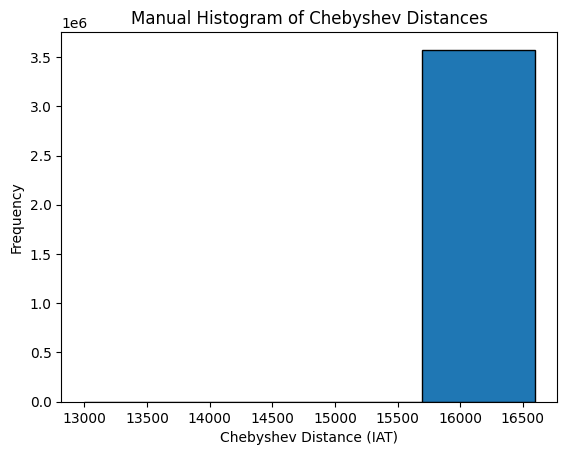

12994.719669818001 16594.819540977


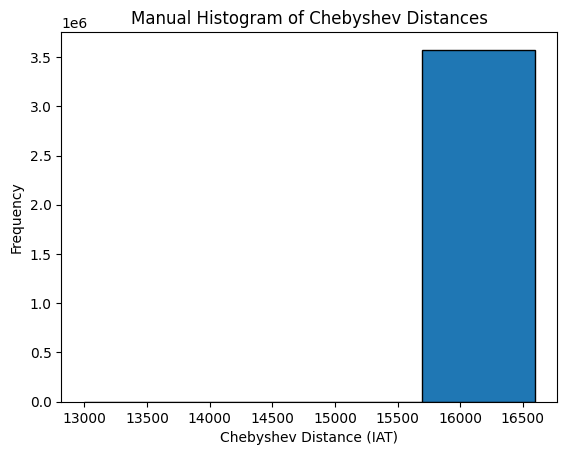

12994.719669818001 16594.819540977


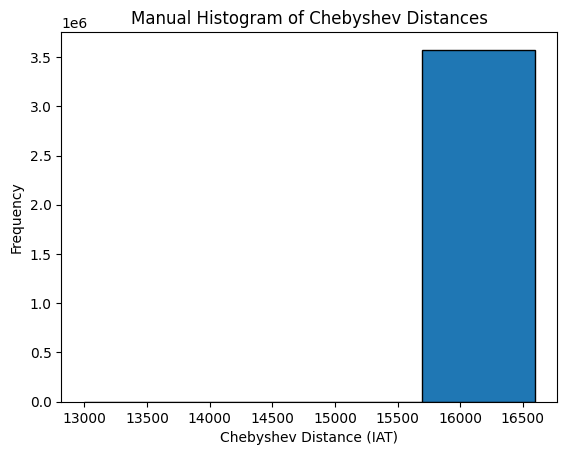

In [ ]:
import matplotlib.pyplot as plt

def manual_histogram(data, bins):
    min_val, max_val = min(data), max(data)
    print(min_val, max_val)
    bin_width = (max_val - min_val) / bins
    bin_edges = [min_val + i * bin_width for i in range(bins + 1)]
    counts = [0] * bins

    for value in data:
        # Find the bin index
        idx = int((value - min_val) / bin_width)
        if idx == bins:  # Handle edge case where value == max_val
            idx -= 1
        counts[idx] += 1

    return bin_edges, counts


for data in [chebyshev_distances_2min, chebyshev_distances_4min, chebyshev_distances_6min]:


    # Create histogram with 20 bins
    bin_edges, counts = manual_histogram(data, bins=4)

    # Plot histogram manually
    plt.bar(
        [ (bin_edges[i] + bin_edges[i+1]) / 2 for i in range(len(counts)) ],
        counts,
        width=(bin_edges[1] - bin_edges[0]),
        edgecolor='black'
    )
    plt.title("Manual Histogram of Chebyshev Distances")
    plt.xlabel("Chebyshev Distance (IAT)")
    plt.ylabel("Frequency")
    plt.show()


211 412


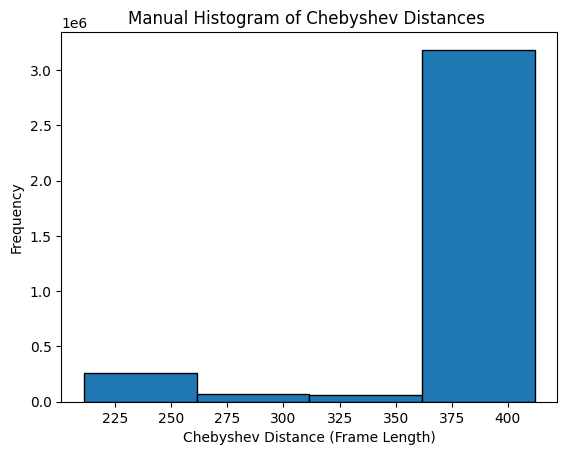

211 412


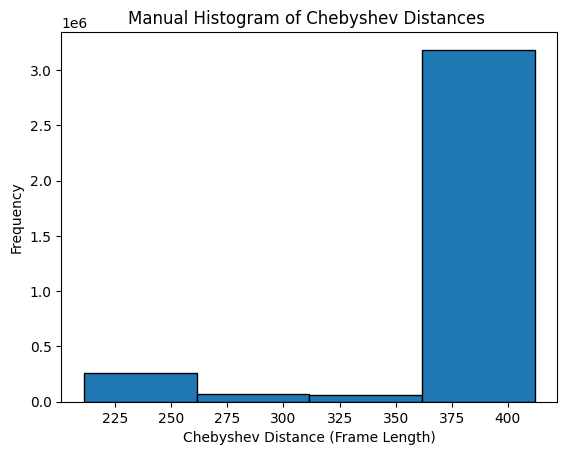

211 412


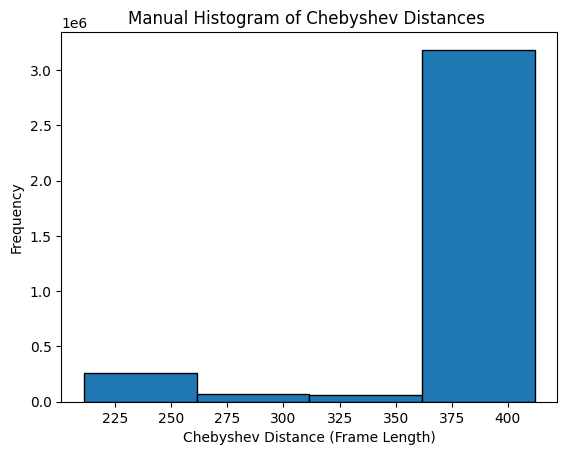

In [147]:
for data in [chebyshev_distances_2min_frame_len, chebyshev_distances_4min_frame_len, chebyshev_distances_6min_frame_len]:

    # Create histogram with 20 bins
    bin_edges, counts = manual_histogram(data, bins=4)

    # Plot histogram manually
    plt.bar(
        [ (bin_edges[i] + bin_edges[i+1]) / 2 for i in range(len(counts)) ],
        counts,
        width=(bin_edges[1] - bin_edges[0]),
        edgecolor='black'
    )
    plt.title("Manual Histogram of Chebyshev Distances ")
    plt.xlabel("Chebyshev Distance (Frame Length)")
    plt.ylabel("Frequency")
    plt.show()


## Same analysis but for control data

In [ ]:
df_control = load_all_csvs(
    '../../DataSets/2017QUT_S7comm/LabelledDataset/output/2017QUT_S7comm/control/',
)   

df_control.head()

✅ Combined DataFrame shape: (870682, 15)


,timestamp,src_ip,dst_ip,src_port,dst_port,l4_proto,app_proto,frame_len,total_header_len,app_payload_len,pair_id,iat_pair,iat_proto_pair,label_attack,filename
0,1.482118e+09,NaN,NaN,-1,-1,unknown,undetected:-1:-1,158,158,0,__,NaN,NaN,0,attacker.pcap
1,1.482118e+09,NaN,NaN,-1,-1,unknown,undetected:-1:-1,60,60,0,__,2.101597,2.101597,0,attacker.pcap
2,1.482118e+09,NaN,NaN,-1,-1,unknown,undetected:-1:-1,60,60,0,__,0.001042,0.001042,0,attacker.pcap
3,1.482118e+09,NaN,NaN,-1,-1,unknown,undetected:-1:-1,60,60,0,__,0.001972,0.001972,0,attacker.pcap
4,1.482118e+09,NaN,NaN,-1,-1,unknown,undetected:-1:-1,153,153,0,__,0.976897,0.976897,0,attacker.pcap


In [ ]:
# select only timestamp, src_ip, dst_ip, l4_proto, app_proto_ frame_len, pair_id, filename
df_control_selected_features = df_control[['timestamp', 'src_ip', 'dst_ip', 'app_proto', 'frame_len', 'pair_id']]

In [ ]:
# print unique app_proto
print(df_control_selected_features['app_proto'].unique())

['undetected:-1:-1' 'NTP' 'NBNS' 'NBDS' 'DHCPv6 Client' 'llmnr' 's7comm']


In [ ]:

df_control_selected_features = df_control_selected_features[df_control_selected_features['app_proto'] != 'undetected:-1:-1']
df_control_selected_features = df_control_selected_features[df_control_selected_features['src_ip'].notna() & df_control_selected_features['dst_ip'].notna()]
print(df_control_selected_features.head())

       timestamp        src_ip           dst_ip app_proto  frame_len  \
8   1.482118e+09  10.10.10.200  255.255.255.255       NTP         90   
16  1.482118e+09  10.10.10.200  255.255.255.255       NTP         90   
18  1.482118e+09   10.10.10.20     10.10.10.255      NBNS         92   
19  1.482118e+09   10.10.10.20     10.10.10.255      NBNS         92   
21  1.482118e+09   10.10.10.20     10.10.10.255      NBNS         92   

                          pair_id  
8   10.10.10.200__255.255.255.255  
16  10.10.10.200__255.255.255.255  
18      10.10.10.20__10.10.10.255  
19      10.10.10.20__10.10.10.255  
21      10.10.10.20__10.10.10.255  


In [ ]:
# same for control data
df_control_grouped = df_control_selected_features.groupby(['app_proto', 'pair_id'])

df_control_grouped.head()

,timestamp,src_ip,dst_ip,app_proto,frame_len,pair_id
8,1.482118e+09,10.10.10.200,255.255.255.255,NTP,90,10.10.10.200__255.255.255.255
16,1.482118e+09,10.10.10.200,255.255.255.255,NTP,90,10.10.10.200__255.255.255.255
18,1.482118e+09,10.10.10.20,10.10.10.255,NBNS,92,10.10.10.20__10.10.10.255
19,1.482118e+09,10.10.10.20,10.10.10.255,NBNS,92,10.10.10.20__10.10.10.255
21,1.482118e+09,10.10.10.20,10.10.10.255,NBNS,92,10.10.10.20__10.10.10.255
25,1.482118e+09,10.10.10.200,255.255.255.255,NTP,90,10.10.10.200__255.255.255.255
33,1.482118e+09,10.10.10.200,255.255.255.255,NTP,90,10.10.10.200__255.255.255.255
40,1.482118e+09,10.10.10.200,255.255.255.255,NTP,90,10.10.10.200__255.255.255.255
148,1.482118e+09,10.10.10.20,10.10.10.255,NBDS,255,10.10.10.20__10.10.10.255
391,1.482119e+09,10.10.10.20,10.10.10.255,NBDS,243,10.10.10.20__10.10.10.255


In [ ]:
flows_control = df_control_grouped.apply(lambda x: x[['timestamp', 'src_ip', 'dst_ip', 'frame_len']].sort_values('timestamp').reset_index(drop=True))

# convert timestamp to datetime
flows_control['timestamp'] = pd.to_datetime(flows_control['timestamp'], unit='s')

flows_control.head()

C:\Users\20115\AppData\Local\Temp\ipykernel_17896\1129284589.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flows_control = df_control_grouped.apply(lambda x: x[['timestamp', 'src_ip', 'dst_ip', 'frame_len']].sort_values('timestamp').reset_index(drop=True))


timestamp  \
app_proto pair_id                                                     
NBDS      10.10.10.20__10.10.10.255 0 2016-12-19 03:30:47.617880106   
                                    1 2016-12-19 03:30:47.617912054   
                                    2 2016-12-19 03:30:47.617969990   
                                    3 2016-12-19 03:35:05.012423992   
                                    4 2016-12-19 03:35:05.012454987   

                                            src_ip        dst_ip  frame_len  
app_proto pair_id                                                            
NBDS      10.10.10.20__10.10.10.255 0  10.10.10.20  10.10.10.255        255  
                                    1  10.10.10.20  10.10.10.255        255  
                                    2  10.10.10.20  10.10.10.255        255  
                                    3  10.10.10.20  10.10.10.255        243  
                                    4  10.10.10.20  10.10.10.255        243

In [ ]:

flows_control['iat'] = flows_control.groupby(level=[0,1])['timestamp'].diff().dt.total_seconds()
flows_control.head()

timestamp  \
app_proto pair_id                                                     
NBDS      10.10.10.20__10.10.10.255 0 2016-12-19 03:30:47.617880106   
                                    1 2016-12-19 03:30:47.617912054   
                                    2 2016-12-19 03:30:47.617969990   
                                    3 2016-12-19 03:35:05.012423992   
                                    4 2016-12-19 03:35:05.012454987   

                                            src_ip        dst_ip  frame_len  \
app_proto pair_id                                                             
NBDS      10.10.10.20__10.10.10.255 0  10.10.10.20  10.10.10.255        255   
                                    1  10.10.10.20  10.10.10.255        255   
                                    2  10.10.10.20  10.10.10.255        255   
                                    3  10.10.10.20  10.10.10.255        243   
                                    4  10.10.10.20  10.10.10.255        243   

                                              iat  
app_proto pair_id                                  
NBDS      10.10.10.20__10.10.10.255 0         NaN  
                                    1    0.000032  
                                    2    0.000058  
                                    3  257.394454  
                                    4    0.000031

In [ ]:
unique_indices_control = flows_control.index.droplevel(-1).unique()
print(unique_indices_control)
print(len(unique_indices_control))


MultiIndex([(  'NBDS',       '10.10.10.20__10.10.10.255'),
            (  'NBNS',       '10.10.10.20__10.10.10.255'),
            (  'NBNS', '169.254.133.89__169.254.255.255'),
            (   'NTP',   '10.10.10.200__255.255.255.255'),
            ( 'llmnr',        '10.10.10.20__224.0.0.252'),
            ( 'llmnr',     '169.254.133.89__224.0.0.252'),
            ('s7comm',        '10.10.10.10__10.10.10.20')],
           names=['app_proto', 'pair_id'])
7


In [ ]:

# Print the length for each flow  => now this is a problem, because it was mentioned that all flows should have the same length.
flow_lengths = flows_control.groupby(level=[0,1]).size()
print(flow_lengths)

app_proto  pair_id                        
NBDS       10.10.10.20__10.10.10.255             225
NBNS       10.10.10.20__10.10.10.255             126
           169.254.133.89__169.254.255.255       198
NTP        10.10.10.200__255.255.255.255       11223
llmnr      10.10.10.20__224.0.0.252               78
           169.254.133.89__224.0.0.252            96
s7comm     10.10.10.10__10.10.10.20           785082
dtype: int64


In [ ]:

flows_control_2min = create_time_windowed_flows(flows_control, 2)
flows_control_4min = create_time_windowed_flows(flows_control, 4)
flows_control_6min = create_time_windowed_flows(flows_control, 6)
print(f"Number of 2-minute flows (control): {len(flows_control_2min)}")
print(f"Number of 4-minute flows (control): {len(flows_control_4min)}")
print(f"Number of 6-minute flows (control): {len(flows_control_6min)}")

Number of 2-minute flows (control): 797028
Number of 4-minute flows (control): 797028
Number of 6-minute flows (control): 797028


## Task2.b: Calculating Chebyshev distance. 
- Using the flows generated for each of the time intervals, our piece of code should compute the Chebyshev distance between every two generated flows per time interval. For the computation of Chebyshev distance, we are not allowed to use any existing libraries, i.e., the programming logic should be implemented by us. We should compute Chebyshev distance between either two flows without attacks or two flows with attack (but not between flow with attack and flow without attack).

- So lets understand what is Chebyshev distance first
- From the Data Mining lecture provided by Professor Ingo Schmitt
  - 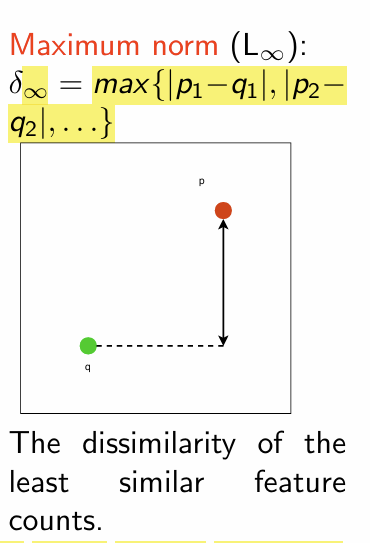
- The Chebyshev distance is a metric used to measure how different two data points (or flows) are by looking only at the largest absolute difference between their corresponding features.
- So, we should compute the absolute difference for every feature and then take the maximum of these differences.
- For example if A = [3,8,2] and B = [1,10,5], then Chebyshev distance is max((|3-1|), |8-10|, |5-2|) = 3

In [123]:


# print on frame_len column
chebyshev_distances_2min_frame_len_control = compute_chebyshev_distances_memory_safe_on_frame_len(flows_control_2min)
chebyshev_distances_4min_frame_len_control = compute_chebyshev_distances_memory_safe_on_frame_len(flows_control_4min)
chebyshev_distances_6min_frame_len_control = compute_chebyshev_distances_memory_safe_on_frame_len(flows_control_6min)
print(len(chebyshev_distances_2min_frame_len_control))
print(chebyshev_distances_2min_frame_len_control[:10])
print(np.unique(chebyshev_distances_2min_frame_len_control, return_counts = True))



797028
[195 195 195 183 183 183 195 195 195 183]
(array([128, 145, 146, 148, 151, 157, 166, 183, 195, 209, 211, 214, 216,
       218, 220, 221, 222, 225, 235, 237, 240, 241]), array([ 59384,  59384,  59302,     82,  59304,     80,      2,    123,
          102,    324,  11935,      2,  59304,  59302,      2,      2,
            2,    716,    104,     72, 238172, 189328]))


In [125]:


# print on iat column
chebyshev_distances_2min_iat_control = compute_chebyshev_distances_memory_safe_on_iat(flows_control_2min)
chebyshev_distances_4min_iat_control = compute_chebyshev_distances_memory_safe_on_iat(flows_control_4min)
chebyshev_distances_6min_iat_control = compute_chebyshev_distances_memory_safe_on_iat(flows_control_6min)
print(len(chebyshev_distances_2min_iat_control))
print(chebyshev_distances_2min_iat_control[:10])
print(np.unique(chebyshev_distances_2min_iat_control, return_counts = True))



797028
[13752.34773707 13752.34770513 13752.34767914 13494.95328307
 13752.34770608 13752.34771299 13108.68328714 13752.34770608
 13752.34753799 13675.46655011]
(array([ 8281.82306004,  8283.22353816, 10152.82182908, ...,
       13752.34773612, 13752.34773612, 13752.34773707], shape=(81721,)), array([   1,    1,    1, ..., 1877,   30,  847], shape=(81721,)))


8281.823060036 13752.347737074


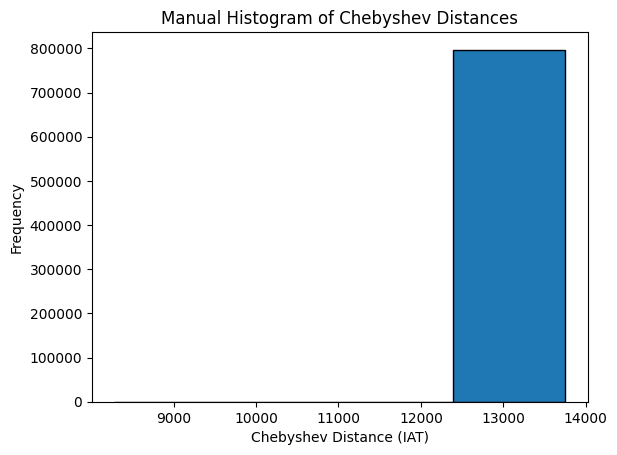

8281.823060036 13752.347737074


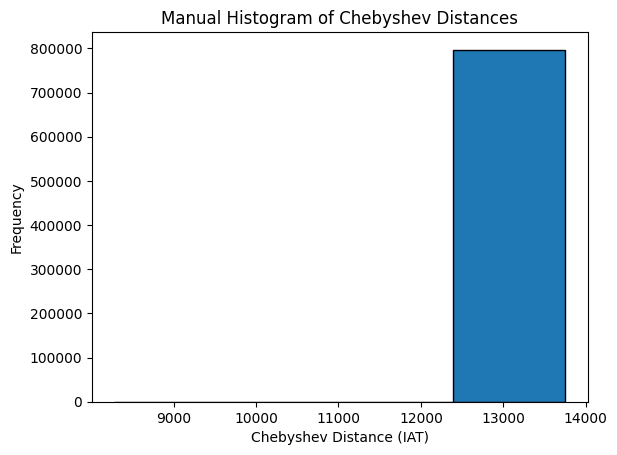

8281.823060036 13752.347737074


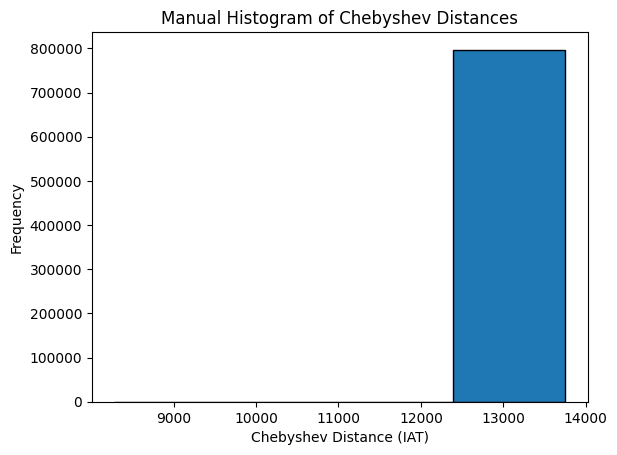

In [142]:
for data in [chebyshev_distances_2min_iat_control, chebyshev_distances_4min_iat_control, chebyshev_distances_6min_iat_control]:


    # Create histogram with 20 bins
    bin_edges, counts = manual_histogram(data, bins=4)

    # Plot histogram manually
    plt.bar(
        [ (bin_edges[i] + bin_edges[i+1]) / 2 for i in range(len(counts)) ],
        counts,
        width=(bin_edges[1] - bin_edges[0]),
        edgecolor='black'
    )
    plt.title("Manual Histogram of Chebyshev Distances")
    plt.xlabel("Chebyshev Distance (IAT)")
    plt.ylabel("Frequency")
    plt.show()


128 241


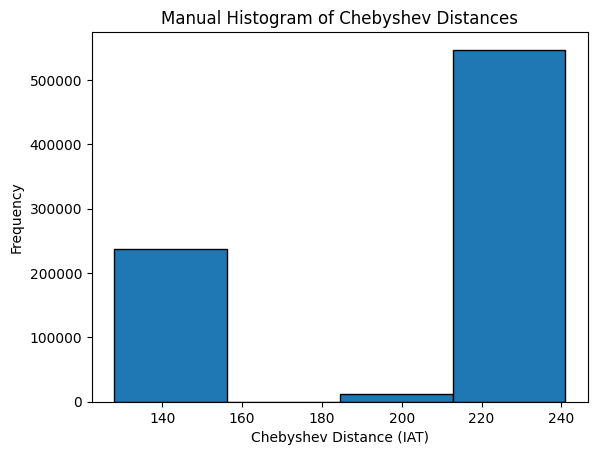

128 241


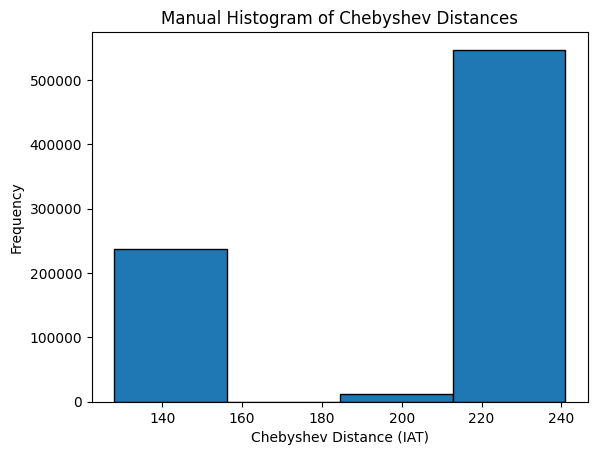

128 241


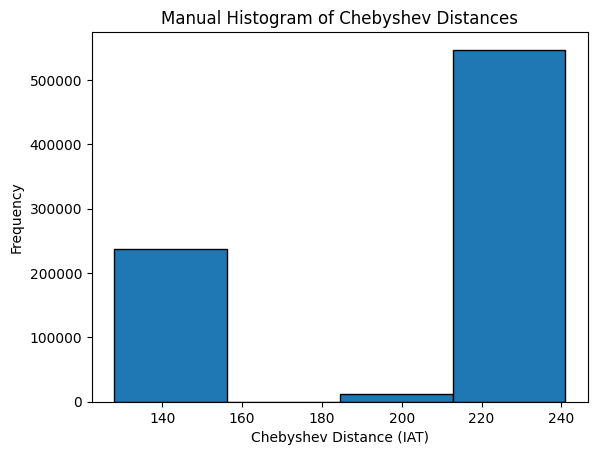

In [146]:

for data in [chebyshev_distances_2min_frame_len_control, chebyshev_distances_4min_frame_len_control, chebyshev_distances_6min_frame_len_control]:


    # Create histogram with 20 bins
    bin_edges, counts = manual_histogram(data, bins=4)

    # Plot histogram manually
    plt.bar(
        [ (bin_edges[i] + bin_edges[i+1]) / 2 for i in range(len(counts)) ],
        counts,
        width=(bin_edges[1] - bin_edges[0]),
        edgecolor='black'
    )
    plt.title("Manual Histogram of Chebyshev Distances")
    plt.xlabel("Chebyshev Distance (IAT)")
    plt.ylabel("Frequency")
    plt.show()
